In [4]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import cvxpy as cp
import os
from google.colab import drive

# ==========================================
# 1. MOUNT GOOGLE DRIVE
# ==========================================
# Bước này sẽ yêu cầu bạn cấp quyền truy cập Drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
!pip install ecos
!pip install scs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 14.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import os
import time

# ==============================================================================
# 1. CÁC HÀM CỐT LÕI (CORE FUNCTIONS)
# ==============================================================================

def build_A_matrix(n_goods, n_slots):
    A = np.zeros((n_slots, n_goods))
    for j in range(n_goods):
        A[j % n_slots, j] = 1.0
    return A

def buyer_best_response_cvx(v_i, p, A, q_i, B_i):
    """Giải bài toán con"""
    m = len(v_i)
    x = cp.Variable(m, nonneg=True)
    effective_price = p + (A.T @ q_i)

    objective = cp.Maximize(B_i * cp.log(v_i @ x + 1e-12))
    constraint = [effective_price @ x <= B_i]

    prob = cp.Problem(objective, constraint)
    try: prob.solve(solver=cp.ECOS)
    except:
        try: prob.solve(solver=cp.SCS)
        except: return np.zeros(m)

    if x.value is None: return np.zeros(m)
    return np.maximum(x.value, 0.0)

def solve_centralized_optimal_fair(valuations, budgets, supply_s, b_mat, A):
    """Solver tìm V* (Dual Target = Primal + Budget)"""
    n, m = valuations.shape
    X = cp.Variable((n, m), nonneg=True)

    utilities = cp.sum(cp.multiply(valuations, X), axis=1)
    primal_utility = cp.sum(cp.multiply(budgets, cp.log(utilities + 1e-12)))
    total_budget_const = np.sum(budgets)

    objective = cp.Maximize(primal_utility + total_budget_const)

    constraints = [cp.sum(X, axis=0) <= supply_s]
    for i in range(n):
        constraints.append(A @ X[i] <= b_mat[i])

    prob = cp.Problem(objective, constraints)
    print(f"--- Solving Solver Target... ---")
    try: prob.solve(solver=cp.ECOS, verbose=False)
    except: prob.solve(solver=cp.SCS, verbose=False)
    return prob.value

def one_sample_sgd_fastlog(
    A, b, supply_s, q0, valuations, budgets, p0,
    lr_p=0.01, lr_q=0.01, num_iters=1000, seed=42, log_freq=10
):
    """SGD trả về lịch sử Objective"""
    rng = np.random.default_rng(seed)
    n, m = valuations.shape

    p = p0.astype(float).copy()
    q = q0.astype(float).copy()

    # Warm start
    X = np.zeros((n, m))
    util = np.zeros(n)
    for j in range(n):
        X[j] = buyer_best_response_cvx(valuations[j], p, A, q[j], budgets[j])
        util[j] = valuations[j] @ X[j]
    D = X.sum(axis=0)

    obj_hist = []

    # Ghi log t=0
    term_p = np.sum(p * supply_s)
    term_q = np.sum(q * b)
    term_u = np.sum(budgets * np.log(util + 1e-12))
    obj_hist.append(term_p + term_q + term_u)

    # Loop
    for t in range(1, num_iters + 1):
        i = int(rng.integers(n))

        D -= X[i]
        x_new = buyer_best_response_cvx(valuations[i], p, A, q[i], budgets[i])
        X[i] = x_new
        util[i] = valuations[i] @ x_new
        D += x_new

        g_p = D - supply_s
        load_i = A @ x_new
        g_q_i = load_i - b[i]

        # Decay Learning Rate
        alpha = lr_p / np.sqrt(t)
        beta  = lr_q / np.sqrt(t)

        p = np.maximum(0, p + alpha * g_p)
        q[i] = np.maximum(0, q[i] + beta * g_q_i)

        if t % log_freq == 0:
            term_p = np.sum(p * supply_s)
            term_q = np.sum(q * b)
            term_u = np.sum(budgets * np.log(util + 1e-12))
            obj_val = term_p + term_q + term_u
            obj_hist.append(term_p + term_q + term_u)
            if t % 500 == 0:
                print(f"Iter {t}/{num_iters} | Obj: {obj_val:.4f}")

    return obj_hist

# ==============================================================================
# 2. MAIN SCRIPT
# ==============================================================================

# --- A. LOAD DATA & SETUP ---
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_10u_24i"
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path): valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
except:
    valuations = np.random.rand(10, 24) + 0.1

N_USERS, M_GOODS = valuations.shape
T_SLOTS = 4

# --- B. PARAMETERS (FIXED SEED) ---
np.random.seed(10)
budgets = np.random.uniform(5.0, 20.0, N_USERS)
supply_s = np.random.uniform(5, 10, M_GOODS)
capacity_b = np.random.uniform(1, 4, (N_USERS, T_SLOTS))

if M_GOODS % T_SLOTS == 0: A_matrix = build_A_matrix(M_GOODS, T_SLOTS)
else: A_matrix = np.zeros((T_SLOTS, M_GOODS))

# --- C. TÌM TARGET (SOLVER) ---
target_val = solve_centralized_optimal_fair(valuations, budgets, supply_s, capacity_b, A_matrix)
print(f"Target V* = {target_val:.4f}")

# --- D. CHẠY THÍ NGHIỆM VỚI 3 STEP SIZES ---
# Định nghĩa 3 mức Learning Rate (Eta)
step_sizes = [0.025, 0.02, 0.005]
labels     = ['High ($\eta=0.025$)', 'Medium ($\eta=0.02$)', 'Low ($\eta=0.005$)']
colors     = ['orange', 'green', 'purple'] # Màu giống hình mẫu

results = {}
LOG_FREQ = 1
NUM_ITERS = 150000 # Chạy 2000 bước để nhìn rõ

print("\n--- Running Experiments ---")
for lr in step_sizes:
    print(f"Running SGD with lr={lr}...")
    p0 = np.ones(M_GOODS)
    q0 = np.zeros((N_USERS, T_SLOTS))

    hist = one_sample_sgd_fastlog(
        A_matrix, capacity_b, supply_s, q0, valuations, budgets, p0,
        lr_p=lr, lr_q=lr, # Gán Step Size
        num_iters=NUM_ITERS, log_freq=LOG_FREQ
    )
    save_dir = "/content/drive/MyDrive/EV_charging_project/experiment_results/Fig4"

    # Tạo thư mục nếu chưa tồn tại
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        print(f"Đã tạo thư mục: {save_dir}")

    # Lưu obj_hist vào file pickle
    file_path = os.path.join(save_dir, f"lr_{lr}.pkl")

    with open(file_path, 'wb') as f:
        pickle.dump(hist, f)

    print(f"✅ Đã lưu thành công obj_hist tại: {file_path}")
    results[lr] = hist

<>:150: SyntaxWarning: invalid escape sequence '\e'
<>:150: SyntaxWarning: invalid escape sequence '\e'
<>:150: SyntaxWarning: invalid escape sequence '\e'
<>:150: SyntaxWarning: invalid escape sequence '\e'
<>:150: SyntaxWarning: invalid escape sequence '\e'
<>:150: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-358680719.py:150: SyntaxWarning: invalid escape sequence '\e'
  labels     = ['High ($\eta=0.025$)', 'Medium ($\eta=0.02$)', 'Low ($\eta=0.005$)']
/tmp/ipython-input-358680719.py:150: SyntaxWarning: invalid escape sequence '\e'
  labels     = ['High ($\eta=0.025$)', 'Medium ($\eta=0.02$)', 'Low ($\eta=0.005$)']
/tmp/ipython-input-358680719.py:150: SyntaxWarning: invalid escape sequence '\e'
  labels     = ['High ($\eta=0.025$)', 'Medium ($\eta=0.02$)', 'Low ($\eta=0.005$)']


--- Solving Solver Target... ---
Target V* = 295.0052

--- Running Experiments ---
Running SGD with lr=0.025...
Iter 500/150000 | Obj: 1013.4044
Iter 1000/150000 | Obj: 894.4076
Iter 1500/150000 | Obj: 815.5266


/usr/local/lib/python3.12/dist-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Iter 2000/150000 | Obj: 763.4668
Iter 2500/150000 | Obj: 729.9059
Iter 3000/150000 | Obj: 704.5586
Iter 3500/150000 | Obj: 691.2752
Iter 4000/150000 | Obj: 676.6113
Iter 4500/150000 | Obj: 666.0458
Iter 5000/150000 | Obj: 656.1763
Iter 5500/150000 | Obj: 647.0545
Iter 6000/150000 | Obj: 638.7963
Iter 6500/150000 | Obj: 630.6194
Iter 7000/150000 | Obj: 622.1034
Iter 7500/150000 | Obj: 616.6790
Iter 8000/150000 | Obj: 607.6937
Iter 8500/150000 | Obj: 600.9297
Iter 9000/150000 | Obj: 593.5305
Iter 9500/150000 | Obj: 586.8584
Iter 10000/150000 | Obj: 581.4881
Iter 10500/150000 | Obj: 573.9611
Iter 11000/150000 | Obj: 568.4883
Iter 11500/150000 | Obj: 562.2109
Iter 12000/150000 | Obj: 556.5629
Iter 12500/150000 | Obj: 550.8878
Iter 13000/150000 | Obj: 544.6485
Iter 13500/150000 | Obj: 539.7319
Iter 14000/150000 | Obj: 534.0606
Iter 14500/150000 | Obj: 529.0657
Iter 15000/150000 | Obj: 524.1901
Iter 15500/150000 | Obj: 518.4884
Iter 16000/150000 | Obj: 513.2829
Iter 16500/150000 | Obj: 508.5

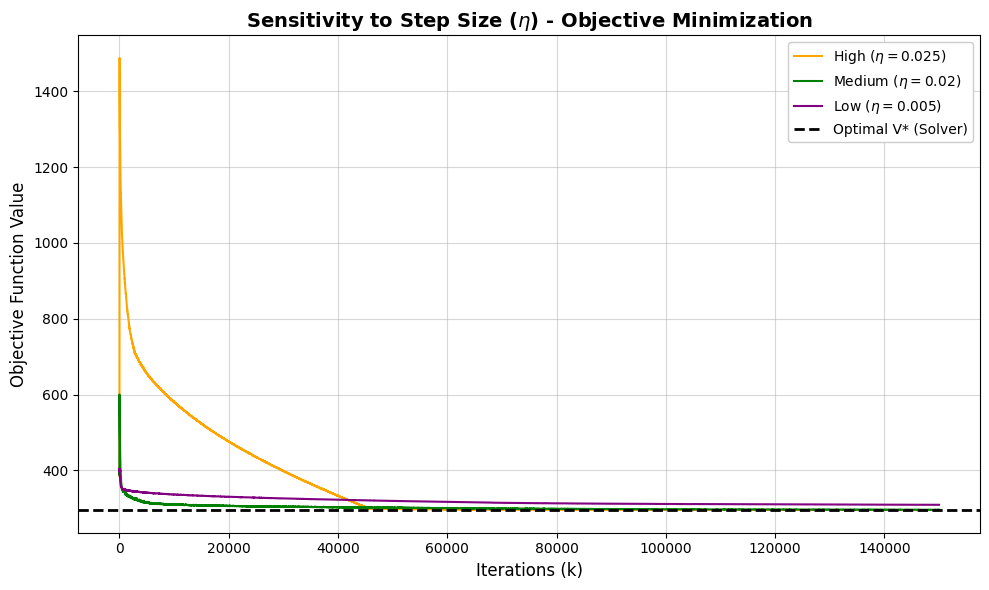

In [ ]:
# ==============================================================================
# 3. VẼ BIỂU ĐỒ (SENSITIVITY ANALYSIS)
# ==============================================================================
plt.figure(figsize=(10, 6))

iterations = np.arange(len(results[step_sizes[0]])) * LOG_FREQ

# 1. Vẽ 3 đường SGD
for i, lr in enumerate(step_sizes):
    plt.plot(iterations, results[lr], color=colors[i], label=labels[i], linewidth=1.5)

# 2. Vẽ đường Solver
plt.axhline(y=target_val, color='black', linestyle='--', linewidth=2, label='Optimal V* (Solver)')

# 3. Trang trí
plt.xlabel('Iterations (k)', fontsize=12)
plt.ylabel('Objective Function Value', fontsize=12)
plt.title(r'Sensitivity to Step Size ($\eta$) - Objective Minimization', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='-', alpha=0.5) # Grid nhạt giống hình mẫu
plt.legend(loc='upper right', framealpha=1.0) # Legend có khung nền trắng


plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import os
import time

# ==============================================================================
# 1. CÁC HÀM CỐT LÕI (CORE FUNCTIONS)
# ==============================================================================

def build_A_matrix(n_goods, n_slots):
    A = np.zeros((n_slots, n_goods))
    for j in range(n_goods):
        A[j % n_slots, j] = 1.0
    return A

def buyer_best_response_cvx(v_i, p, A, q_i, B_i):
    """Giải bài toán con"""
    m = len(v_i)
    x = cp.Variable(m, nonneg=True)
    effective_price = p + (A.T @ q_i)

    objective = cp.Maximize(B_i * cp.log(v_i @ x + 1e-12))
    constraint = [effective_price @ x <= B_i]

    prob = cp.Problem(objective, constraint)
    try: prob.solve(solver=cp.ECOS)
    except:
        try: prob.solve(solver=cp.SCS)
        except: return np.zeros(m)

    if x.value is None: return np.zeros(m)
    return np.maximum(x.value, 0.0)

def solve_centralized_optimal_fair(valuations, budgets, supply_s, b_mat, A):
    """Solver tìm V* (Dual Target = Primal + Budget)"""
    n, m = valuations.shape
    X = cp.Variable((n, m), nonneg=True)

    utilities = cp.sum(cp.multiply(valuations, X), axis=1)
    primal_utility = cp.sum(cp.multiply(budgets, cp.log(utilities + 1e-12)))
    total_budget_const = np.sum(budgets)

    objective = cp.Maximize(primal_utility + total_budget_const)

    constraints = [cp.sum(X, axis=0) <= supply_s]
    for i in range(n):
        constraints.append(A @ X[i] <= b_mat[i])

    prob = cp.Problem(objective, constraints)
    print(f"--- Solving Solver Target... ---")
    try: prob.solve(solver=cp.ECOS, verbose=False)
    except: prob.solve(solver=cp.SCS, verbose=False)
    return prob.value

def one_sample_sgd_fastlog(
    A, b, supply_s, q0, valuations, budgets, p0,
    lr_p=0.01, lr_q=0.01, num_iters=1000, seed=42, log_freq=10
):
    """SGD trả về lịch sử Objective"""
    rng = np.random.default_rng(seed)
    n, m = valuations.shape

    p = p0.astype(float).copy()
    q = q0.astype(float).copy()

    # Warm start
    X = np.zeros((n, m))
    util = np.zeros(n)
    for j in range(n):
        X[j] = buyer_best_response_cvx(valuations[j], p, A, q[j], budgets[j])
        util[j] = valuations[j] @ X[j]
    D = X.sum(axis=0)

    obj_hist = []

    # Ghi log t=0
    term_p = np.sum(p * supply_s)
    term_q = np.sum(q * b)
    term_u = np.sum(budgets * np.log(util + 1e-12))
    obj_hist.append(term_p + term_q + term_u)

    # Loop
    for t in range(1, num_iters + 1):
        i = int(rng.integers(n))

        D -= X[i]
        x_new = buyer_best_response_cvx(valuations[i], p, A, q[i], budgets[i])
        X[i] = x_new
        util[i] = valuations[i] @ x_new
        D += x_new

        g_p = D - supply_s
        load_i = A @ x_new
        g_q_i = load_i - b[i]

        # Decay Learning Rate
        alpha = lr_p / np.sqrt(t)
        beta  = lr_q / np.sqrt(t)

        p = np.maximum(1e-3, p + alpha * g_p)
        q[i] = np.maximum(0, q[i] + beta * g_q_i)

        if t % log_freq == 0:
            term_p = np.sum(p * supply_s)
            term_q = np.sum(q * b)
            term_u = np.sum(budgets * np.log(util + 1e-12))
            obj_val = term_p + term_q + term_u
            obj_hist.append(term_p + term_q + term_u)
            if t % 500 == 0:
                print(f"Iter {t}/{num_iters} | Obj: {obj_val:.4f}")

    return obj_hist

# ==============================================================================
# 2. MAIN SCRIPT
# ==============================================================================

# --- A. LOAD DATA & SETUP ---
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_10u_24i"
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path): valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
except:
    valuations = np.random.rand(10, 24) + 0.1

N_USERS, M_GOODS = valuations.shape
T_SLOTS = 4

# --- B. PARAMETERS (FIXED SEED) ---
np.random.seed(10)
budgets = np.random.uniform(5.0, 20.0, N_USERS)
supply_s = np.random.uniform(5, 10, M_GOODS)
capacity_b = np.random.uniform(1, 4, (N_USERS, T_SLOTS))

if M_GOODS % T_SLOTS == 0: A_matrix = build_A_matrix(M_GOODS, T_SLOTS)
else: A_matrix = np.zeros((T_SLOTS, M_GOODS))

# --- C. TÌM TARGET (SOLVER) ---
target_val = solve_centralized_optimal_fair(valuations, budgets, supply_s, capacity_b, A_matrix)
print(f"Target V* = {target_val:.4f}")

# --- D. CHẠY THÍ NGHIỆM VỚI 3 STEP SIZES ---
# Định nghĩa 3 mức Learning Rate (Eta)
step_sizes = [0.02, 0.005, 0.001]
labels     = ['High ($\eta=0.02$)', 'Medium ($\eta=0.005$)', 'Low ($\eta=0.001$)']
colors     = ['orange', 'green', 'purple'] # Màu giống hình mẫu

results = {}
LOG_FREQ = 1
NUM_ITERS = 150000 # Chạy 2000 bước để nhìn rõ

print("\n--- Running Experiments ---")
for lr in step_sizes:
    print(f"Running SGD with lr={lr}...")
    p0 = np.ones(M_GOODS)
    q0 = np.zeros((N_USERS, T_SLOTS))

    hist = one_sample_sgd_fastlog(
        A_matrix, capacity_b, supply_s, q0, valuations, budgets, p0,
        lr_p=lr, lr_q=lr, # Gán Step Size
        num_iters=NUM_ITERS, log_freq=LOG_FREQ
    )
    save_dir = "/content/drive/MyDrive/EV_charging_project/experiment_results/Fig4_new"

    # Tạo thư mục nếu chưa tồn tại
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        print(f"Đã tạo thư mục: {save_dir}")

    # Lưu obj_hist vào file pickle
    file_path = os.path.join(save_dir, f"lr_{lr}.pkl")

    with open(file_path, 'wb') as f:
        pickle.dump(hist, f)

    print(f"✅ Đã lưu thành công obj_hist tại: {file_path}")
    results[lr] = hist

<>:150: SyntaxWarning: invalid escape sequence '\e'
<>:150: SyntaxWarning: invalid escape sequence '\e'
<>:150: SyntaxWarning: invalid escape sequence '\e'
<>:150: SyntaxWarning: invalid escape sequence '\e'
<>:150: SyntaxWarning: invalid escape sequence '\e'
<>:150: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-3252329407.py:150: SyntaxWarning: invalid escape sequence '\e'
  labels     = ['High ($\eta=0.02$)', 'Medium ($\eta=0.005$)', 'Low ($\eta=0.001$)']
/tmp/ipython-input-3252329407.py:150: SyntaxWarning: invalid escape sequence '\e'
  labels     = ['High ($\eta=0.02$)', 'Medium ($\eta=0.005$)', 'Low ($\eta=0.001$)']
/tmp/ipython-input-3252329407.py:150: SyntaxWarning: invalid escape sequence '\e'
  labels     = ['High ($\eta=0.02$)', 'Medium ($\eta=0.005$)', 'Low ($\eta=0.001$)']


--- Solving Solver Target... ---
Target V* = 295.0053

--- Running Experiments ---
Running SGD with lr=0.02...
Iter 500/150000 | Obj: 350.2396
Iter 1000/150000 | Obj: 343.0307
Iter 1500/150000 | Obj: 334.0194
Iter 2000/150000 | Obj: 332.2592
Iter 2500/150000 | Obj: 325.6529
Iter 3000/150000 | Obj: 323.1572
Iter 3500/150000 | Obj: 322.5838
Iter 4000/150000 | Obj: 318.5068
Iter 4500/150000 | Obj: 316.9186
Iter 5000/150000 | Obj: 315.3686
Iter 5500/150000 | Obj: 313.4762
Iter 6000/150000 | Obj: 313.3837
Iter 6500/150000 | Obj: 312.2571
Iter 7000/150000 | Obj: 311.4672
Iter 7500/150000 | Obj: 312.2949
Iter 8000/150000 | Obj: 310.9338
Iter 8500/150000 | Obj: 311.1137
Iter 9000/150000 | Obj: 310.3008
Iter 9500/150000 | Obj: 310.6561
Iter 10000/150000 | Obj: 309.4381
Iter 10500/150000 | Obj: 309.8605
Iter 11000/150000 | Obj: 309.3921
Iter 11500/150000 | Obj: 309.1787
Iter 12000/150000 | Obj: 309.1441
Iter 12500/150000 | Obj: 309.1133
Iter 13000/150000 | Obj: 308.7301
Iter 13500/150000 | Obj: 

--- Loading Data from Drive ---
✅ Loaded: lr_0.02.pkl (Length: 150001)
✅ Loaded: lr_0.005.pkl (Length: 150001)
✅ Loaded: lr_0.001.pkl (Length: 150001)


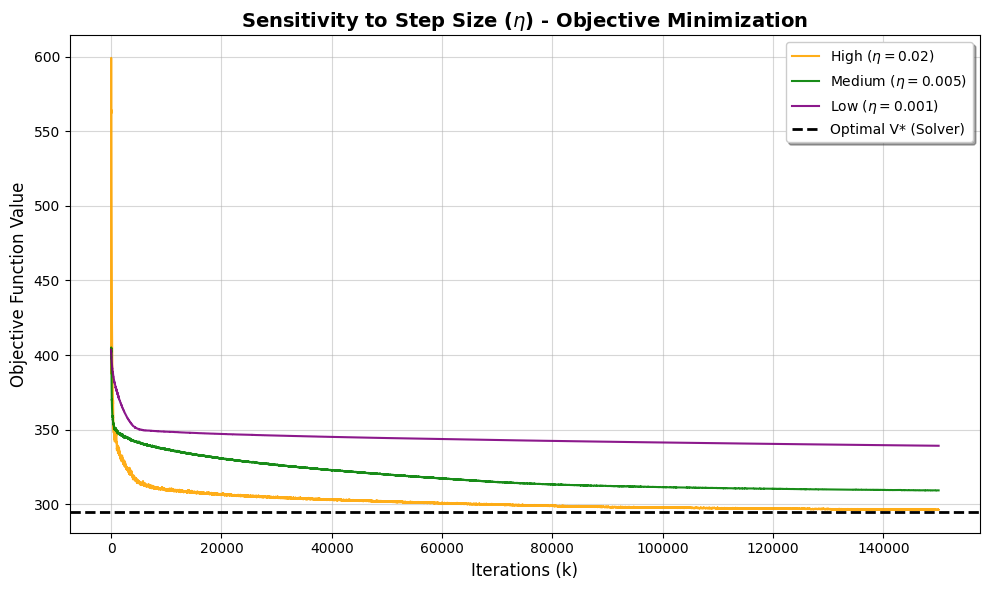

In [7]:
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. CẤU HÌNH & LOAD DỮ LIỆU
# ==============================================================================

# Đường dẫn chứa file
SAVE_DIR = "/content/drive/MyDrive/EV_charging_project/experiment_results/Fig4_new"

# Các tham số cấu hình y hệt lúc chạy
step_sizes = [0.02, 0.005, 0.001]
labels     = [r'High ($\eta=0.02$)', r'Medium ($\eta=0.005$)', r'Low ($\eta=0.001$)']
colors     = ['orange', 'green', 'purple']
LOG_FREQ   = 1

target_val = 295.0053
results = {}

print("--- Loading Data from Drive ---")
for lr in step_sizes:
    file_name = f"lr_{lr}.pkl"
    file_path = os.path.join(SAVE_DIR, file_name)

    try:
        with open(file_path, 'rb') as f:
            data = pickle.load(f)
            results[lr] = data
            print(f"✅ Loaded: {file_name} (Length: {len(data)})")
    except FileNotFoundError:
        print(f"❌ File not found: {file_path}")
        # Tạo dữ liệu giả để code không crash nếu thiếu file (Optional)
        results[lr] = [target_val] * 150000

# ==============================================================================
# 2. VẼ BIỂU ĐỒ (SENSITIVITY ANALYSIS)
# ==============================================================================
if len(results) > 0:
    plt.figure(figsize=(10, 6))

    # Lấy trục X từ dữ liệu đầu tiên load được
    first_lr = step_sizes[0]
    if first_lr in results:
        iterations = np.arange(len(results[first_lr])) * LOG_FREQ
    else:
        iterations = np.arange(150000) # Fallback

    # 1. Vẽ 3 đường SGD
    for i, lr in enumerate(step_sizes):
        if lr in results:
            # Vẽ raw data để thấy độ dao động (Sensitivity)
            plt.plot(iterations, results[lr],
                     color=colors[i],
                     label=labels[i],
                     linewidth=1.5,
                     alpha=0.9)

    # 2. Vẽ đường Solver Benchmark
    plt.axhline(y=target_val, color='black', linestyle='--', linewidth=2, label='Optimal V* (Solver)')

    # 3. Trang trí
    plt.xlabel('Iterations (k)', fontsize=12)
    plt.ylabel('Objective Function Value', fontsize=12)
    plt.title(r'Sensitivity to Step Size ($\eta$) - Objective Minimization', fontsize=14, fontweight='bold')

    # Grid & Legend đẹp
    plt.grid(True, linestyle='-', alpha=0.5)
    plt.legend(loc='upper right', framealpha=1.0, shadow=True)

    # Giới hạn trục Y (Optional: để nhìn rõ vùng hội tụ hơn nếu biên độ dao động quá lớn)
    # plt.ylim(350, 400)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Không có dữ liệu nào được load để vẽ hình.")

--- Loading Data from Drive ---
✅ Loaded: lr_0.02.pkl (Length: 150001)
✅ Loaded: lr_0.005.pkl (Length: 150001)
✅ Loaded: lr_0.001.pkl (Length: 150001)


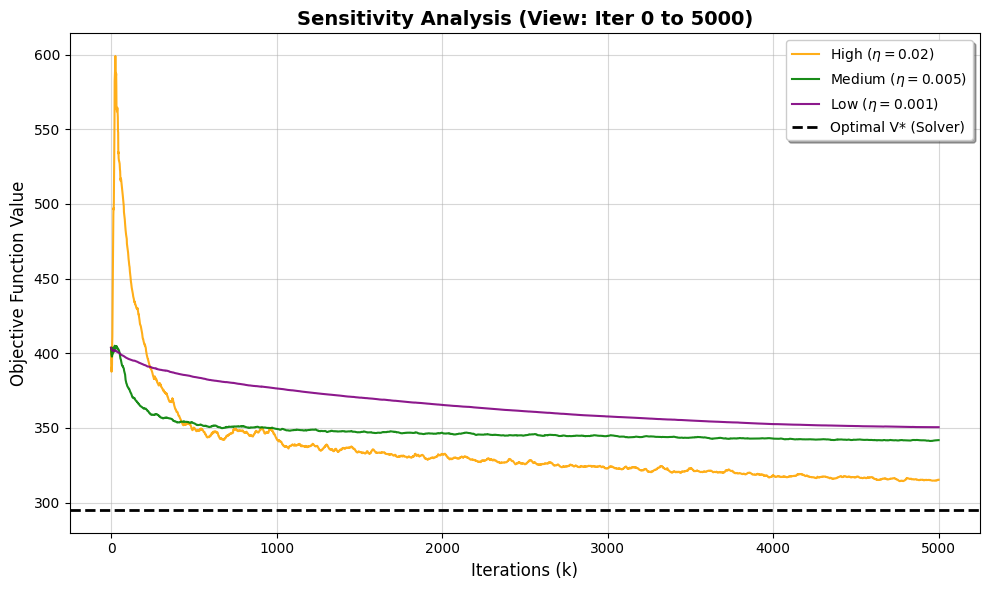

In [13]:
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. CẤU HÌNH & LOAD DỮ LIỆU
# ==============================================================================

SAVE_DIR = "/content/drive/MyDrive/EV_charging_project/experiment_results/Fig4_new"

step_sizes = [0.02, 0.005, 0.001]
labels     = [r'High ($\eta=0.02$)', r'Medium ($\eta=0.005$)', r'Low ($\eta=0.001$)']
colors     = ['orange', 'green', 'purple']
LOG_FREQ   = 1

target_val = 295.0053
results = {}

print("--- Loading Data from Drive ---")
for lr in step_sizes:
    file_name = f"lr_{lr}.pkl"
    file_path = os.path.join(SAVE_DIR, file_name)
    try:
        with open(file_path, 'rb') as f:
            data = pickle.load(f)
            results[lr] = data
            print(f"✅ Loaded: {file_name} (Length: {len(data)})")
    except FileNotFoundError:
        print(f"❌ File not found: {file_path}")
        # Dữ liệu giả để test nếu không tìm thấy file
        results[lr] = [target_val + 100*np.exp(-0.001*i) for i in range(150000)]

# ==============================================================================
# 2. CẤU HÌNH KHOẢNG NHÌN (VIEW RANGE) - CHỈNH Ở ĐÂY
# ==============================================================================

# Bạn muốn xem từ iteration nào đến iteration nào?
START_ITER = 0        # Bắt đầu (Mặc định 0)
END_ITER   = 5000     # Kết thúc (Mặc định None để vẽ đến cuối cùng)
                      # Ví dụ: Để 5000 để xem 5000 vòng lặp đầu tiên

# ==============================================================================
# 3. VẼ BIỂU ĐỒ
# ==============================================================================
if len(results) > 0:
    plt.figure(figsize=(10, 6))

    # Lấy key đầu tiên để tạo trục X chuẩn
    first_lr = step_sizes[0]

    # 1. Tính toán chỉ số cắt (Slicing Indices) dựa trên LOG_FREQ
    # Vì dữ liệu được lưu thưa (mỗi LOG_FREQ bước lưu 1 lần)
    start_idx = int(START_ITER / LOG_FREQ)

    if END_ITER is None:
        end_idx = None # Lấy đến hết
        display_end = "End"
    else:
        end_idx = int(END_ITER / LOG_FREQ)
        display_end = END_ITER

    # Tạo trục X cho khoảng đã chọn
    if first_lr in results:
        full_iterations = np.arange(len(results[first_lr])) * LOG_FREQ
        # Cắt trục X
        iterations_slice = full_iterations[start_idx:end_idx]
    else:
        iterations_slice = []

    # 2. Vẽ 3 đường SGD (Đã cắt theo khoảng)
    for i, lr in enumerate(step_sizes):
        if lr in results:
            # Cắt dữ liệu trục Y tương ứng
            y_data_slice = results[lr][start_idx:end_idx]

            # Kiểm tra độ dài cho khớp (phòng hờ)
            min_len = min(len(iterations_slice), len(y_data_slice))

            plt.plot(iterations_slice[:min_len], y_data_slice[:min_len],
                     color=colors[i],
                     label=labels[i],
                     linewidth=1.5,
                     alpha=0.9)

    # 3. Vẽ đường Solver Benchmark
    plt.axhline(y=target_val, color='black', linestyle='--', linewidth=2, label='Optimal V* (Solver)')

    # 4. Trang trí
    plt.xlabel('Iterations (k)', fontsize=12)
    plt.ylabel('Objective Function Value', fontsize=12)
    plt.title(f'Sensitivity Analysis (View: Iter {START_ITER} to {display_end})', fontsize=14, fontweight='bold')

    plt.grid(True, linestyle='-', alpha=0.5)
    plt.legend(loc='upper right', framealpha=1.0, shadow=True)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Không có dữ liệu nào được load để vẽ hình.")